<a href="https://colab.research.google.com/github/maneroshni15-droid/my-dashboards/blob/main/Customer_Segmentation_KMeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import urllib.request

url = "https://raw.githubusercontent.com/SteffiPeTaffy/machineLearningAZ/master/Machine%20Learning%20A-Z%20Template%20Folder/Part%204%20-%20Clustering/Section%2025%20-%20Hierarchical%20Clustering/Mall_Customers.csv"
urllib.request.urlretrieve(url, "Mall_Customers.csv")
print("Dataset downloaded successfully!")

Dataset downloaded successfully!


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("Mall_Customers.csv")

# First look at the data
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (200, 5)

First 5 rows:


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [6]:
# Let's understand our data better
print("Column Names:", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nAny Missing Values?\n", df.isnull().sum())
print("\nBasic Statistics:")
df.describe()

Column Names: ['CustomerID', 'Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

Data Types:
 CustomerID                 int64
Genre                     object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

Any Missing Values?
 CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Basic Statistics:


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


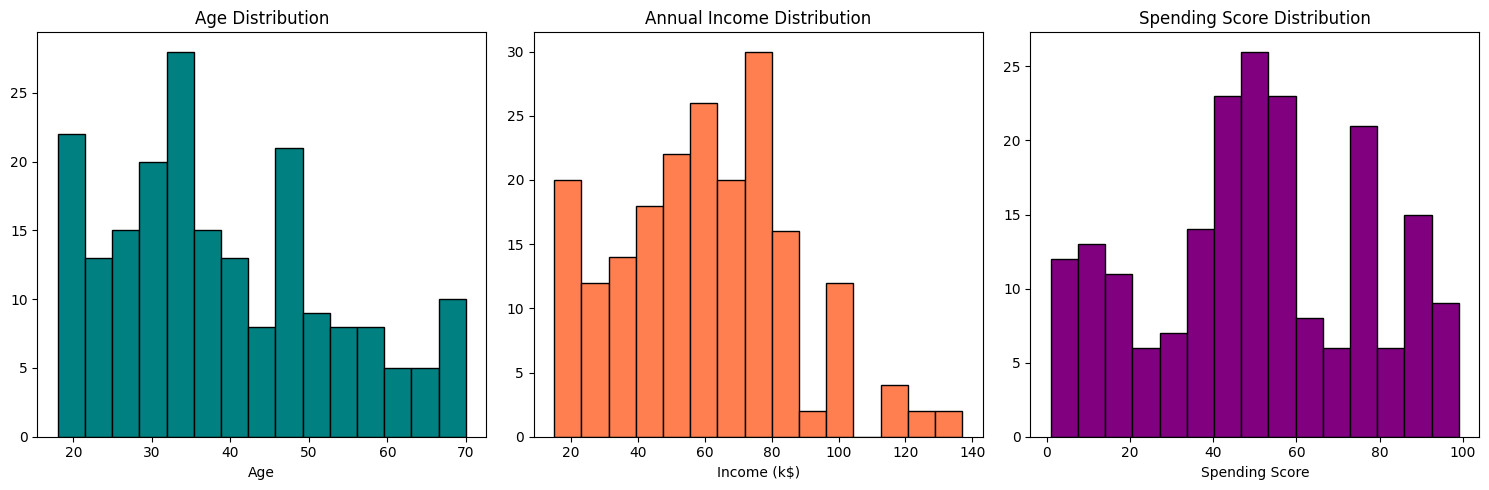

In [8]:
# Let's visualize the data distribution
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.hist(df['Age'], bins=15, color='teal', edgecolor='black')
plt.title('Age Distribution')
plt.xlabel('Age')

plt.subplot(1,3,2)
plt.hist(df['Annual Income (k$)'], bins=15, color='coral', edgecolor='black')
plt.title('Annual Income Distribution')
plt.xlabel('Income (k$)')

plt.subplot(1,3,3)
plt.hist(df['Spending Score (1-100)'], bins=15, color='purple', edgecolor='black')
plt.title('Spending Score Distribution')
plt.xlabel('Spending Score')

plt.tight_layout()
plt.show()

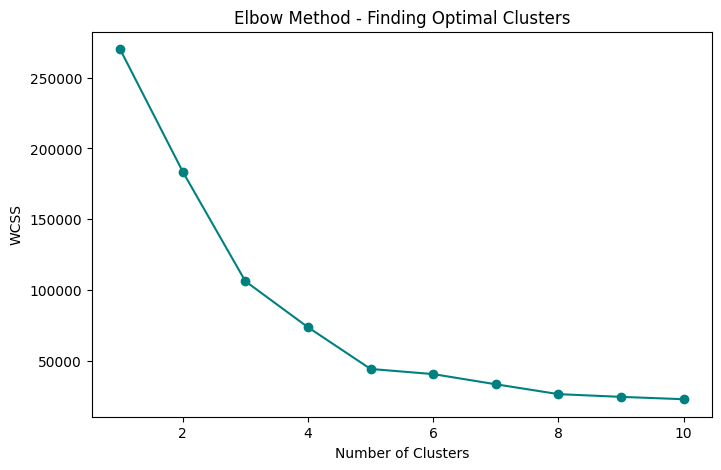

In [9]:
from sklearn.cluster import KMeans

# We use Annual Income & Spending Score for clustering
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

# Find the optimal number of clusters using Elbow Method
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Plot the Elbow curve
plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker='o', color='teal')
plt.title('Elbow Method - Finding Optimal Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

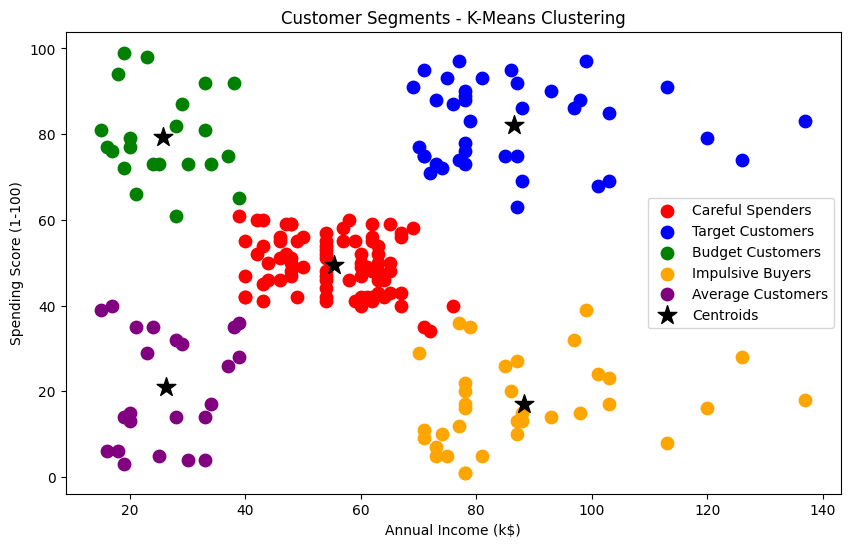

In [10]:
# Apply K-Means with 5 clusters
kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster'] = kmeans.fit_predict(X)

# Visualize the clusters
plt.figure(figsize=(10,6))
colors = ['red', 'blue', 'green', 'orange', 'purple']
labels = ['Careful Spenders', 'Target Customers',
          'Budget Customers', 'Impulsive Buyers', 'Average Customers']

for i in range(5):
    plt.scatter(X[df['Cluster']==i, 0], X[df['Cluster']==i, 1],
                c=colors[i], label=labels[i], s=80)

plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=200, c='black', marker='*', label='Centroids')

plt.title('Customer Segments - K-Means Clustering')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

In [12]:
# Cluster Summary - Business Insights
summary = df.groupby('Cluster')[['Age', 'Annual Income (k$)',
                                  'Spending Score (1-100)']].mean().round(1)
summary['Segment Name'] = ['Careful Spenders', 'Target Customers',
                            'Budget Customers', 'Impulsive Buyers',
                            'Average Customers']
summary['Count'] = df['Cluster'].value_counts().sort_index()
print("=== Customer Segment Summary ===")
print(summary)

=== Customer Segment Summary ===
          Age  Annual Income (k$)  Spending Score (1-100)       Segment Name  \
Cluster                                                                        
0        42.7                55.3                    49.5   Careful Spenders   
1        32.7                86.5                    82.1   Target Customers   
2        25.3                25.7                    79.4   Budget Customers   
3        41.1                88.2                    17.1   Impulsive Buyers   
4        45.2                26.3                    20.9  Average Customers   

         Count  
Cluster         
0           81  
1           39  
2           22  
3           35  
4           23  


In [13]:
print("""
=== BUSINESS INSIGHTS & RECOMMENDATIONS ===

1. TARGET CUSTOMERS (39 customers) - HIGH PRIORITY
   - Age: ~33 | Income: $86k | Spending: 82/100
   - Action: Launch premium loyalty programs & exclusive offers

2. BUDGET CUSTOMERS (22 customers) - ENGAGE CAREFULLY
   - Age: ~25 | Income: $25k | Spending: 79/100
   - Action: Offer EMI options, student deals & flash sales

3. IMPULSIVE BUYERS (35 customers) - UNTAPPED POTENTIAL
   - Age: ~41 | Income: $88k | Spending: 17/100
   - Action: Send personalized premium product recommendations

4. CAREFUL SPENDERS (81 customers) - LARGEST GROUP
   - Age: ~43 | Income: $55k | Spending: 49/100
   - Action: Mid-range deals, value-for-money campaigns

5. AVERAGE CUSTOMERS (23 customers) - NEEDS NURTURING
   - Age: ~45 | Income: $26k | Spending: 21/100
   - Action: Budget bundles & discount vouchers

KEY FINDING: Impulsive Buyers earn $88k but only spend 17/100 —
biggest growth opportunity for the business!
""")


=== BUSINESS INSIGHTS & RECOMMENDATIONS ===

1. TARGET CUSTOMERS (39 customers) - HIGH PRIORITY
   - Age: ~33 | Income: $86k | Spending: 82/100
   - Action: Launch premium loyalty programs & exclusive offers
   
2. BUDGET CUSTOMERS (22 customers) - ENGAGE CAREFULLY  
   - Age: ~25 | Income: $25k | Spending: 79/100
   - Action: Offer EMI options, student deals & flash sales

3. IMPULSIVE BUYERS (35 customers) - UNTAPPED POTENTIAL
   - Age: ~41 | Income: $88k | Spending: 17/100
   - Action: Send personalized premium product recommendations
   
4. CAREFUL SPENDERS (81 customers) - LARGEST GROUP
   - Age: ~43 | Income: $55k | Spending: 49/100
   - Action: Mid-range deals, value-for-money campaigns

5. AVERAGE CUSTOMERS (23 customers) - NEEDS NURTURING
   - Age: ~45 | Income: $26k | Spending: 21/100
   - Action: Budget bundles & discount vouchers

KEY FINDING: Impulsive Buyers earn $88k but only spend 17/100 — 
biggest growth opportunity for the business!

